# **Mod_3 Assignment 1**

In [1]:
# Step 0
import pandas as pd
import numpy as np
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
print('Shape:', df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Step 1
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [3]:
# Step 2
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)
print('Median used:', median_age)
print('Missing Age now:', df['Age'].isnull().sum())

Median used: 28.0
Missing Age now: 0


In [4]:
# Step 3
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)
print('Mode used:', mode_embarked)
print('Missing Embarked:', df['Embarked'].isnull().sum())

Mode used: S
Missing Embarked: 0


In [5]:
# Step 4
df = df.drop(columns=['Cabin'])
print('Columns now:', df.shape[1])

Columns now: 11


In [6]:
# Step 5
print('Duplicates:', df.duplicated().sum())

Duplicates: 0


In [7]:
# Step 6
df['Survived_label'] = df['Survived'].map({0: 'No', 1: 'Yes'})
df[['Survived', 'Survived_label']].head()

,Survived,Survived_label
0,0,No
1,1,Yes
2,1,Yes
3,1,Yes
4,0,No


In [8]:
# Step 7
df['Sex'] = df['Sex'].str.strip().str.lower()
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [9]:
# Step 8
print('Missing per column:')
print(df.isnull().sum())
print()
print('Final shape:', df.shape)

Missing per column:
PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Embarked          0
Survived_label    0
dtype: int64

Final shape: (891, 12)


# **Mod_3 Assignment 2**

In [10]:
# Step 0
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

In [11]:
# Step 1
cols = ['MonthlyCharges', 'TotalCharges']
df[cols].describe().round(2)

,MonthlyCharges,TotalCharges
count,7043.00,7043.00
mean,64.76,2279.73
std,30.09,2266.79
min,18.25,0.00
25%,35.50,398.55
50%,70.35,1394.55
75%,89.85,3786.60
max,118.75,8684.80


In [12]:
# Step 2
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
X = df[cols]
X_mm = mm.fit_transform(X)
X_mm_df = pd.DataFrame(X_mm, columns=cols)
X_mm_df.agg(['min', 'max']).round(2)

,MonthlyCharges,TotalCharges
min,0.0,0.0
max,1.0,1.0


In [13]:
# Step 3
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
X_std = std.fit_transform(X)
X_std_df = pd.DataFrame(X_std, columns=cols)
X_std_df.describe().round(2)

,MonthlyCharges,TotalCharges
count,7043.00,7043.00
mean,-0.00,-0.00
std,1.00,1.00
min,-1.55,-1.01
25%,-0.97,-0.83
50%,0.19,-0.39
75%,0.83,0.66
max,1.79,2.83


In [14]:
# Step 4
from sklearn.preprocessing import RobustScaler
rb = RobustScaler()
X_rb = rb.fit_transform(X)
X_rb_df = pd.DataFrame(X_rb, columns=cols)
X_rb_df.describe().round(2)

,MonthlyCharges,TotalCharges
count,7043.00,7043.00
mean,-0.10,0.26
std,0.55,0.67
min,-0.96,-0.41
25%,-0.64,-0.29
50%,0.00,0.00
75%,0.36,0.71
max,0.89,2.15


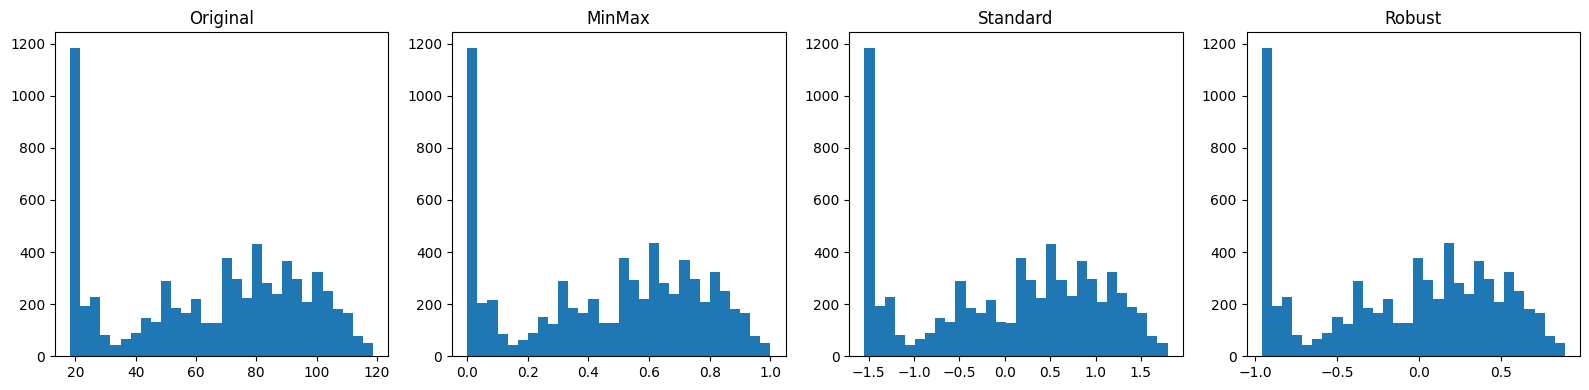

In [15]:
# Step 5
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].hist(df['MonthlyCharges'], bins=30); ax[0].set_title('Original')
ax[1].hist(X_mm_df['MonthlyCharges'], bins=30); ax[1].set_title('MinMax')
ax[2].hist(X_std_df['MonthlyCharges'], bins=30); ax[2].set_title('Standard')
ax[3].hist(X_rb_df['MonthlyCharges'], bins=30); ax[3].set_title('Robust')
plt.tight_layout()
plt.show()

In [16]:
# Step 6
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print('Train mean:', X_train_s.mean(axis=0).round(2))
print('Test mean:', X_test_s.mean(axis=0).round(2))

Train mean: [-0.  0.]
Test mean: [-0.02 -0.02]


# **Mod_3 Assignment 3**

In [17]:
# Step 0
import pandas as pd
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

In [18]:
# Step 1
obj_cols = df.select_dtypes(include='object').columns.tolist()
print('Total object columns:', len(obj_cols))
print(obj_cols)

Total object columns: 18
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [19]:
# Step 2
df['gender'].value_counts()

,count
gender,
Male,3555
Female,3488


In [20]:
# Step 3
dummies = pd.get_dummies(df['InternetService'], prefix='Internet')
print('Shape:', dummies.shape)
dummies.head()

Shape: (7043, 3)


,Internet_DSL,Internet_Fiber optic,Internet_No
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,False,True,False


In [21]:
# Step 4
dummies2 = pd.get_dummies(df['InternetService'], prefix='Internet', drop_first=True)
print('With drop_first:', dummies2.shape)
dummies2.head()

With drop_first: (7043, 2)


,Internet_Fiber optic,Internet_No
0,False,False
1,False,False
2,False,False
3,False,False
4,True,False


In [22]:
# Step 5
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(df[['TechSupport']])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['TechSupport']))
encoded_df.head()

,TechSupport_No,TechSupport_No internet service,TechSupport_Yes
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,0.0,0.0,1.0
4,1.0,0.0,0.0


In [23]:
# Step 6
df['Partner_bin'] = df['Partner'].map({'No': 0, 'Yes': 1})
df[['Partner', 'Partner_bin']].head()

,Partner,Partner_bin
0,Yes,1
1,No,0
2,No,0
3,No,0
4,No,0


In [24]:
# Step 7
multi = pd.get_dummies(df[['gender', 'InternetService', 'TechSupport', 'Contract']], drop_first=True)
print('Shape:', multi.shape)
multi.head()

Shape: (7043, 7)


,gender_Male,InternetService_Fiber optic,InternetService_No,TechSupport_No internet service,TechSupport_Yes,Contract_One year,Contract_Two year
0,False,False,False,False,False,False,False
1,True,False,False,False,False,True,False
2,True,False,False,False,False,False,False
3,True,False,False,False,True,True,False
4,False,True,False,False,False,False,False


# **Mod_3 Assignment 4**

In [25]:
# Step 0
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn_bin'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [26]:
# Step 1
num = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']]
cat = pd.get_dummies(df[['Contract', 'PaymentMethod']], drop_first=True)
X = pd.concat([num, cat], axis=1)
y = df['Churn_bin']
print('X shape:', X.shape)
print('Features:', list(X.columns))

X shape: (7043, 9)
Features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [27]:
# Step 2
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(X, y, random_state=42)
mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)
mi_scores.round(4)

,0
tenure,0.0772
Contract_Two year,0.0546
MonthlyCharges,0.0432
TotalCharges,0.0431
PaymentMethod_Electronic check,0.0369
PaymentMethod_Credit card (automatic),0.0169
SeniorCitizen,0.0138
Contract_One year,0.0116
PaymentMethod_Mailed check,0.0008


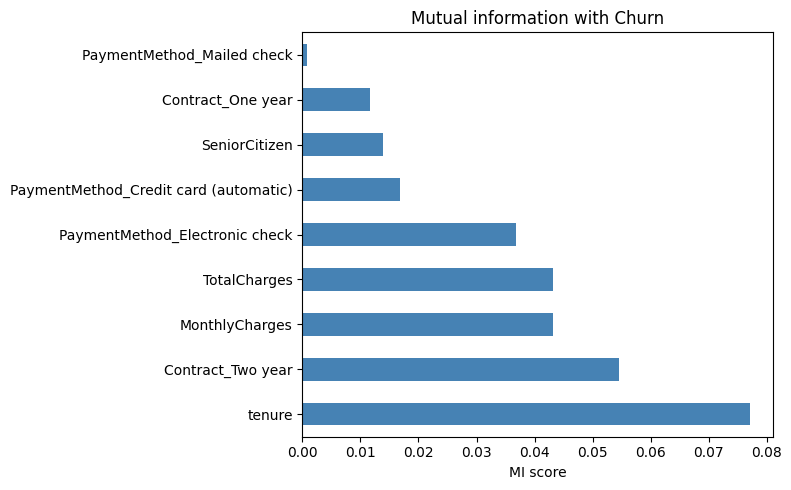

In [28]:
# Step 3
plt.figure(figsize=(8, 5))
mi_scores.plot(kind='barh', color='steelblue')
plt.title('Mutual information with Churn')
plt.xlabel('MI score')
plt.tight_layout()
plt.show()

In [29]:
# Step 4
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=3)
rfe.fit(X_scaled, y)
result = pd.DataFrame({'feature': X.columns, 'kept': rfe.support_, 'rank': rfe.ranking_})
result.sort_values('rank')

,feature,kept,rank
0,tenure,True,1
1,MonthlyCharges,True,1
5,Contract_Two year,True,1
2,TotalCharges,False,2
4,Contract_One year,False,3
7,PaymentMethod_Electronic check,False,4
3,SeniorCitizen,False,5
8,PaymentMethod_Mailed check,False,6
6,PaymentMethod_Credit card (automatic),False,7


In [30]:
# Step 5
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
m_all = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
print('All features:', round(accuracy_score(y_te, m_all.predict(X_te)), 4))
idx = np.where(rfe.support_)[0]
m_top = LogisticRegression(max_iter=1000).fit(X_tr[:, idx], y_tr)
print('Top 3:', round(accuracy_score(y_te, m_top.predict(X_te[:, idx])), 4))

All features: 0.802
Top 3: 0.8006


# **Mod_3 Assignment 5**

In [1]:
# Step 0
import pandas as pd
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn_bin'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [2]:
# Step 1
num_features = ['tenure', 'MonthlyCharges', 'SeniorCitizen']
cat_features = ['Contract', 'InternetService', 'PaymentMethod']
X = df[num_features + cat_features]
y = df['Churn_bin']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (5282, 6), Test: (1761, 6)


In [3]:
# Step 2
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

In [4]:
# Step 3
from sklearn.preprocessing import OneHotEncoder
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [5]:
# Step 4
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_features),
    ('cat', cat_pipe, cat_features)
])

In [6]:
# Step 5
from sklearn.ensemble import RandomForestClassifier
full_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])
full_pipe

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'SeniorCitizen']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Contract',
                                                   'InternetService',
                                                   'PaymentMethod'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [7]:
# Step 6
full_pipe.fit(X_train, y_train)
print('Trained.')

Trained.


In [8]:
# Step 7
acc = full_pipe.score(X_test, y_test)
print(f'Random Forest test accuracy: {acc:.4f}')

Random Forest test accuracy: 0.7677


In [9]:
# Step 8
import joblib
joblib.dump(full_pipe, 'rf_pipeline.joblib')
loaded = joblib.load('rf_pipeline.joblib')
print('Loaded model test accuracy:', round(loaded.score(X_test, y_test), 4))

Loaded model test accuracy: 0.7677
